In [222]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [223]:
df = pd.read_csv('../sample_data/Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [224]:
df.info()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [225]:
df.describe()


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [226]:
df_selected = df.iloc[:,2:]
df_selected

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [227]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df_selected.drop('Purchased',axis=1),df_selected['Purchased'],test_size = 0.3 ,random_state=0)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((280, 2), (120, 2), (280,), (120,))

In [228]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [229]:
x_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [230]:
x_trained_scale = pd.DataFrame(x_train_scaled,columns = x_train.columns)
x_trained_scale.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,3.489272e-17,6.344132e-17
std,1.001791e+00,1.001791e+00
min,-1.947491e+00,-1.584970e+00
25%,-7.710131e-01,-7.752370e-01
50%,-8.473441e-02,2.003677e-02
75%,7.976239e-01,5.261201e-01
max,2.170181e+00,2.319101e+00


In [231]:
np.round(x_trained_scale.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


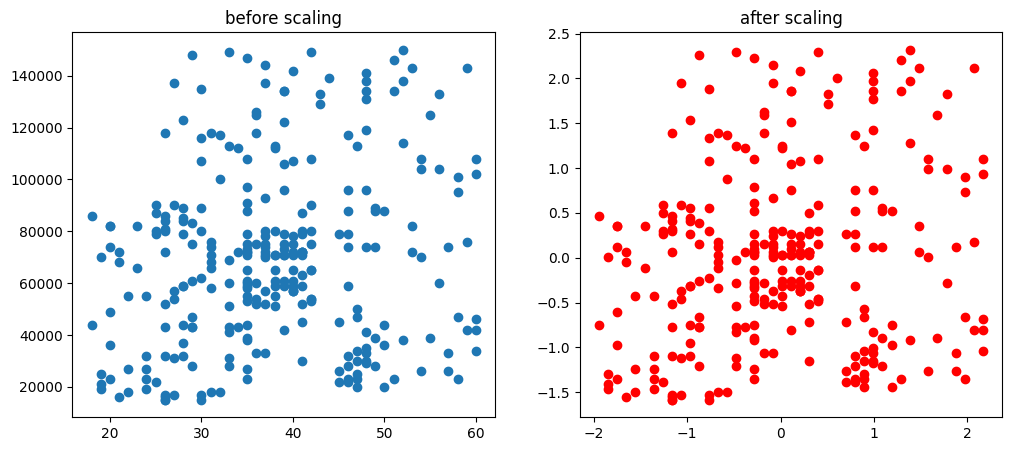

In [232]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title('before scaling')

ax2.scatter(x_trained_scale['Age'],x_trained_scale['EstimatedSalary'],color='red')
ax2.set_title('after scaling')

plt.show()

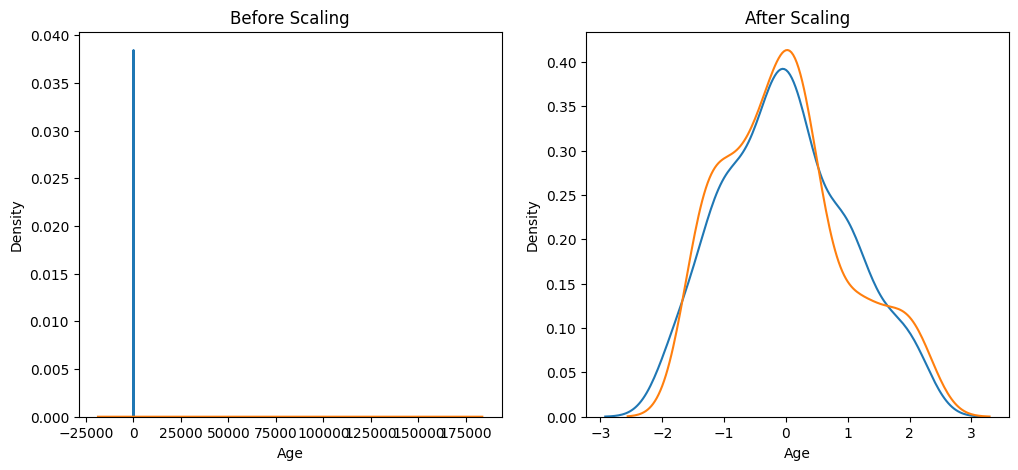

In [233]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize = (12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'],ax = ax1)
sns.kdeplot(x_train['EstimatedSalary'],ax = ax1)

ax2.set_title('After Scaling')
sns.kdeplot(x_trained_scale['Age'],ax = ax2)
sns.kdeplot(x_trained_scale['EstimatedSalary'],ax = ax2)

plt.show()

kde = kernel density estimation

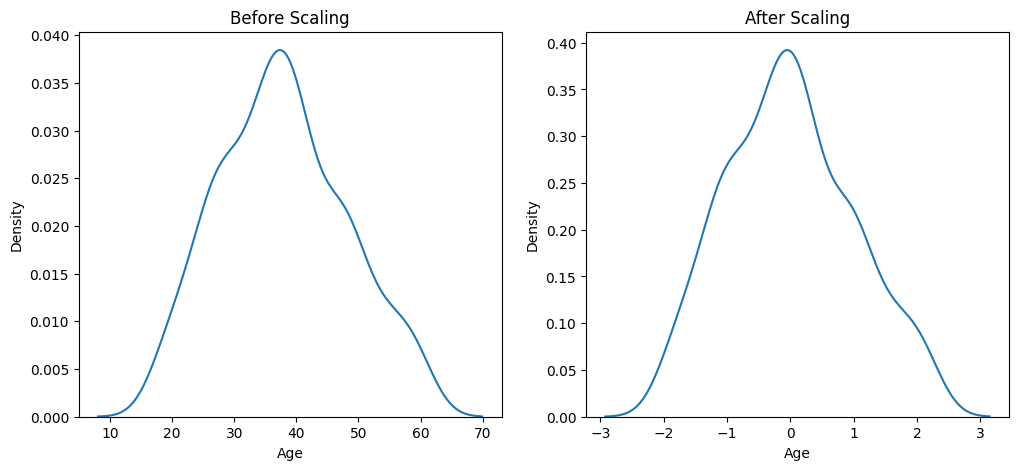

In [234]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize = (12,5))


ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'],ax=ax1)
sns.kdeplot(x_trained_scale['Age'],ax=ax2)

ax2.set_title('After Scaling')
plt.show()

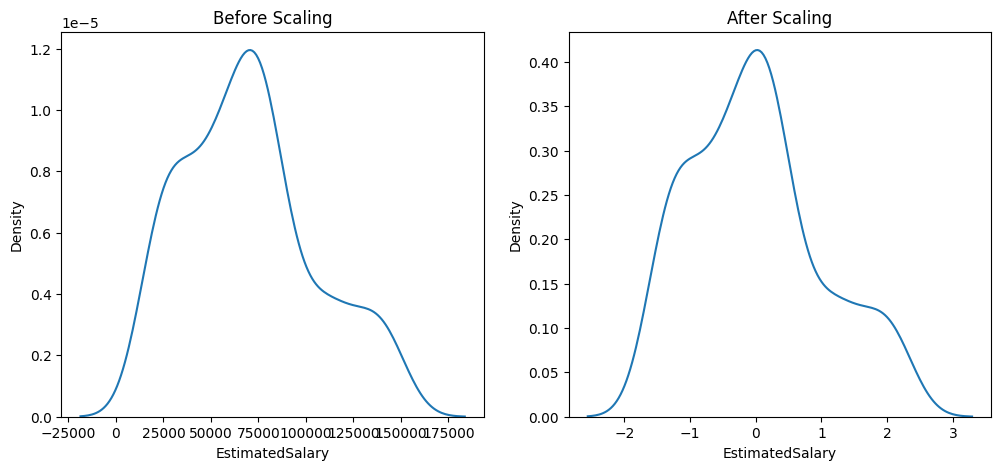

In [235]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(x_trained_scale['EstimatedSalary'],ax=ax2)

plt.show()

#why scaling is important

In [236]:
from sklearn.linear_model import  LogisticRegression
lr_scaled = LogisticRegression()
lr = LogisticRegression()


In [237]:
lr_scaled.fit(x_trained_scale,y_train)
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [238]:
pred_scaled = lr_scaled.predict(x_test_scaled)
pred = lr.predict(x_test)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [239]:
from sklearn.metrics import accuracy_score

print('Accuracy of Scaled inputs',accuracy_score(y_test,pred_scaled))
print('Accuracy of Non Scaled inputs',accuracy_score(y_test,pred))

Accuracy of Scaled inputs 0.8666666666666667
Accuracy of Non Scaled inputs 0.875


effect of outlier

In [240]:
df_out = df.iloc[:,2:]
df_out


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [241]:
df_out = pd.concat([
    df_out,
    pd.DataFrame({
        'Age':[5,90,95],
        'EstimatedSalary':[1000,250000,350000],
        'Purchased':[0,1,1]
    })
], ignore_index=True)



In [242]:
df_out

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


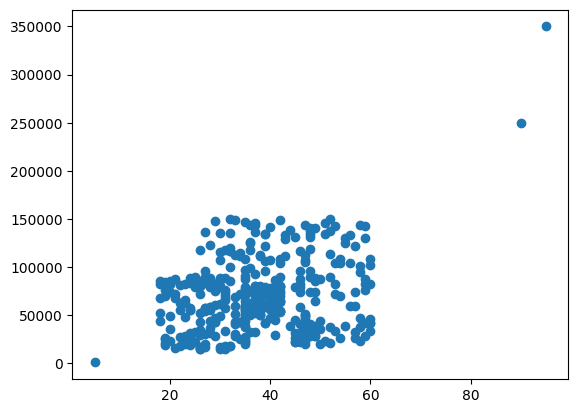

In [243]:
plt.scatter(df_out['Age'],df_out['EstimatedSalary'])

In [244]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df_out.drop('Purchased',axis=1),df_out['Purchased'],test_size=0.2,random_state=42)
x_train.shape, x_test.shape

((322, 2), (81, 2))

In [245]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
scale.fit(x_train)
x_train_s = scale.transform(x_train)
x_test_s = scale.transform(x_test)
x_train_s, x_test_s

(array([[-1.08424420e-01, -3.85373407e-01],
        [ 9.68572906e-01,  3.52199225e-01],
        [-1.00592219e+00, -3.85373407e-01],
        [ 6.99323574e-01, -1.12294604e+00],
        [-4.67423529e-01, -1.04664542e+00],
        [ 1.60824911e-01, -3.34506329e-01],
        [ 2.50574689e-01, -3.87032116e-03],
        [-5.57173306e-01,  1.21693955e+00],
        [ 5.19824020e-01, -8.43177110e-01],
        [ 1.23782224e+00,  1.97994572e+00],
        [ 3.40324466e-01, -2.07338634e-01],
        [-8.26422638e-01, -1.12294604e+00],
        [-1.08424420e-01,  1.99597991e-01],
        [-1.09567197e+00,  3.52199225e-01],
        [ 7.10751341e-02, -3.34506329e-01],
        [-1.08424420e-01,  1.82734449e+00],
        [-6.46923083e-01, -2.93038602e-02],
        [-2.87923975e-01, -5.63408180e-01],
        [ 6.99323574e-01,  4.69967569e-02],
        [ 1.77632090e+00,  1.82734449e+00],
        [ 6.99323574e-01,  6.06534616e-01],
        [-3.77673752e-01,  1.01347124e+00],
        [ 7.10751341e-02, -2.930

In [246]:
x_train_saved = pd.DataFrame(x_train_s, columns = x_train.columns)
x_test_saved = pd.DataFrame(x_test_s, columns = x_test.columns)
np.round(x_train_saved.describe(),1)



,Age,EstimatedSalary
count,322.0,322.0
mean,0.0,0.0
std,1.0,1.0
min,-3.0,-1.8
25%,-0.6,-0.7
50%,-0.1,-0.0
75%,0.7,0.4
max,5.1,7.1


In [247]:
np.round(x_test_saved.describe(),1)

,Age,EstimatedSalary
count,81.0,81.0
mean,-0.2,-0.2
std,1.0,0.8
min,-1.8,-1.5
25%,-1.0,-0.7
50%,-0.3,-0.3
75%,0.7,0.3
max,2.0,1.9


mean 0 and std 1 are not gaurenteed for test data

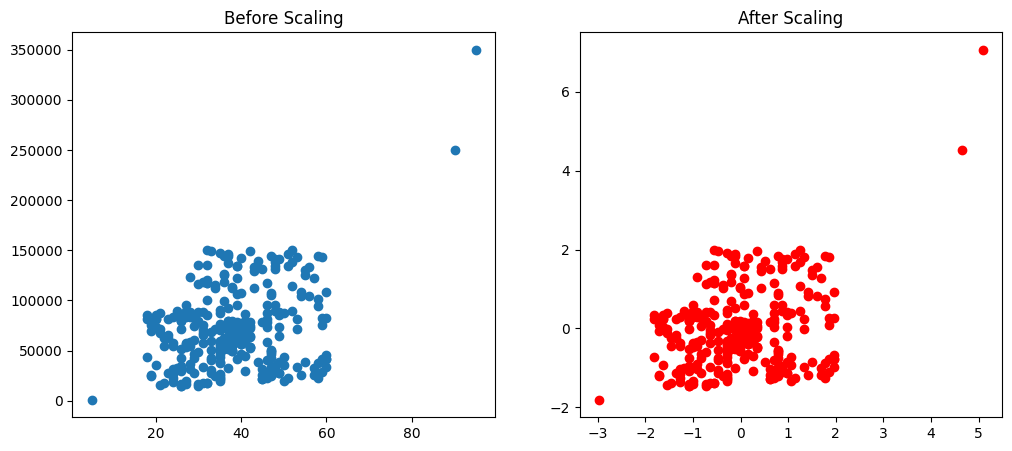

In [248]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_saved['Age'], x_train_saved['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

this means outlierr cant be handeled in standardization
